# Stage 1e: CB1 Decoder Baseline — Llama-3.2-3B-Instruct (Attempt 3: Numeric Labels)
## Zero-Shot and Few-Shot | Generalised LoRA for Cyberbullying Detection

---

### Attempt History (documented for thesis)

| Attempt | Change | ZS Macro F1 | FS Macro F1 | Outcome |
|---------|--------|-------------|-------------|---------|
| 1 — Original | Text labels, full-sequence decode | 0.0404 | 0.0404 | Complete class collapse — decode bug, parser searched entire prompt |
| 2 — Bug fixes | New-token decode `outputs[0][input_len:]`, word-boundary parser | 0.0911 | 0.0492 | ZS real; FS collapsed — model echoed `Tweet/Category:` template back |
| **3 — This run** | **Numeric labels 0–5, digit-first parser** | TBD | TBD | Model outputs one character; pattern-echo impossible |

### Why numeric labels fix the few-shot collapse
The 3B model has insufficient capacity to simultaneously follow instructions
and resist the pull of a repeated 12-example prompt pattern. When every
example ends `Category: other_cyberbullying`, the model learns to echo that
structure. Switching to single-digit outputs (0–5) removes the pattern:
there is nothing to echo. The old 4-class notebook (cb_multi_labeled_balanced)
used this approach and achieved FS Macro F1 = 0.64, confirming the fix works.

**Primary Metric:** Macro F1 | **Secondary Metric:** MCC | **Seed:** 42

---
## Step 1: Install Required Libraries

In [2]:
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    bitsandbytes \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn \
    tqdm

print("All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 46.3 MB/s eta 0:00:00
All libraries installed successfully.


---
## Step 2: Imports and Setup

In [3]:
import os, re, random, gc
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
)
from google.colab import drive, userdata


def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"All random seeds fixed to {seed}.")


set_all_seeds(42)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TOKENIZERS_CLEAN_UP_TOKENIZATION_SPACES"] = "false"

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

All random seeds fixed to 42.
Mounted at /content/drive
Google Drive mounted.
Device: GPU
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Key change:** `MAX_NEW_TOKENS = 3` (was 10) and `OUTPUT_DIR` uses `-Numeric` suffix to keep results separate from Attempt 2.

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
CB1_PATH   = "/content/drive/MyDrive/Datasets/cb1.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Results/CB1_Decoders/Llama-3.2-3B-Numeric"

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME  = "meta-llama/Llama-3.2-3B-Instruct"
MODEL_SHORT = "Llama-3.2-3B"

# ── Generation settings ────────────────────────────────────────────────────────
# Numeric labels: model outputs a single digit → max 3 new tokens is enough
MAX_NEW_TOKENS = 3
MAX_INPUT_LEN  = 512

# ── Dataset split ──────────────────────────────────────────────────────────────
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# ── Label mapping ──────────────────────────────────────────────────────────────
# Numeric labels: model outputs 0-5, not text strings.
LABEL_MAPPING = {
    "not_cyberbullying":   0,
    "gender":              1,
    "religion":            2,
    "ethnicity":           3,
    "age":                 4,
    "other_cyberbullying": 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())
NUM_LABELS   = len(LABEL_MAPPING)

# ── Few-shot settings ─────────────────────────────────────────────────────────
N_EXAMPLES_PER_CLASS = 2   # 2 per class × 6 classes = 12 total

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Model          : {MODEL_NAME}")
print(f"  Output format  : NUMERIC (0-5)  ← key change vs Attempt 2")
print(f"  Max new tokens : {MAX_NEW_TOKENS}  (digit only — was 10)")
print(f"  Labels ({NUM_LABELS})     : {TARGET_NAMES}")
print(f"  Few-shot       : {N_EXAMPLES_PER_CLASS} per class = {N_EXAMPLES_PER_CLASS * NUM_LABELS} total")
print(f"  Seed           : {RANDOM_STATE}")
print(f"  Output         : {OUTPUT_DIR}")

Configuration loaded.
  Model          : meta-llama/Llama-3.2-3B-Instruct
  Output format  : NUMERIC (0-5)  ← key change vs Attempt 2
  Max new tokens : 3  (digit only — was 10)
  Labels (6)     : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']
  Few-shot       : 2 per class = 12 total
  Seed           : 42
  Output         : /content/drive/MyDrive/Results/CB1_Decoders/Llama-3.2-3B-Numeric


---
## Step 4: Text Preprocessing

In [5]:
def preprocess_text_for_llm(text: str) -> str:
    """LLM-optimised tweet preprocessing — preserves casing, numbers, punctuation."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\bRT\s+@\w+:\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"([!?.])\1+", r"\1", text)
    return text if len(text.split()) >= 3 else ""


_t = "RT @user123: Check http://example.com !!! @someone is so dumb"
print("Before:", _t)
print("After :", preprocess_text_for_llm(_t))
print("Preprocessing function defined.")

Before: RT @user123: Check http://example.com !!! @someone is so dumb
After : Check [URL] ! [USER] is so dumb
Preprocessing function defined.


---
## Step 5: Load and Clean CB1 Dataset

In [6]:
print("=" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("=" * 60)

df = pd.read_csv(CB1_PATH)
print(f"[1] Raw dataset: {len(df):,} samples")

df = df.rename(columns={"tweet_text": "text", "cyberbullying_type": "label"})

corrupt_mask = df["text"].astype(str).str.strip().isin(
    ["#NAME?", "#REF!", "#VALUE!", "#N/A", "nan", ""])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[2] After corrupt removal: {len(df):,}")

df["text"] = df["text"].apply(preprocess_text_for_llm)
df = df[df["text"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[3] After preprocessing: {len(df):,}")

tlc = df.groupby("text")["label"].nunique()
conflicting = tlc[tlc > 1].index
df = df[~df["text"].isin(conflicting)].reset_index(drop=True)
print(f"[4] After conflict removal: {len(df):,}")

before = len(df)
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"[5] After dedup: {len(df):,} (removed {before - len(df):,})")

unknown = set(df["label"].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown) == 0, f"Unknown labels: {unknown}"

print("\nClass distribution:")
for label, count in df["label"].value_counts().items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")

CB1 DATASET LOADING & CLEANING
[1] Raw dataset: 47,692 samples
[2] After corrupt removal: 47,692
[3] After preprocessing: 46,942
[4] After conflict removal: 43,692
[5] After dedup: 43,334 (removed 358)

Class distribution:
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334


---
## Step 6: Stratified Split with Near-Duplicate Removal

Identical to Attempts 1 & 2 — same test set, fair comparison.

In [7]:
print("=" * 60)
print("DATASET SPLITTING  (identical to Attempts 1 & 2)")
print("=" * 60)

train_df, test_df = train_test_split(
    df, test_size=TEST_RATIO,
    random_state=RANDOM_STATE, stratify=df["label"])
print(f"Initial -> Train: {len(train_df):,} | Test: {len(test_df):,}")

print(f"Near-duplicate check (threshold={SIMILARITY_THRESHOLD})...")
all_texts    = list(train_df["text"].values) + list(test_df["text"].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_df)]
test_vecs    = tfidf_matrix[len(train_df):]

leaked = []
for start in range(0, len(test_df), 500):
    end  = min(start + 500, len(test_df))
    sims = cosine_similarity(test_vecs[start:end], train_vecs)
    mask = sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked.extend(test_df.index[start:end][mask].tolist())

if leaked:
    leaked_samples = test_df.loc[leaked]
    test_df  = test_df.drop(leaked).reset_index(drop=True)
    train_df = pd.concat([train_df, leaked_samples], ignore_index=True)
    print(f"  Moved {len(leaked)} near-duplicates to train.")
else:
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    print("  No near-duplicates found.")

overlap = set(train_df["text"]).intersection(set(test_df["text"]))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} samples!"
print("Zero train/test overlap confirmed.")
print(f"Final -> Train: {len(train_df):,} | Test: {len(test_df):,}")

x_test = test_df["text"].values
y_test  = test_df["label"].map(LABEL_MAPPING).values
print(f"\nTest set ready: {len(x_test):,} samples")

DATASET SPLITTING  (identical to Attempts 1 & 2)
Initial -> Train: 32,500 | Test: 10,834
Near-duplicate check (threshold=0.9)...
  Moved 504 near-duplicates to train.
Zero train/test overlap confirmed.
Final -> Train: 33,004 | Test: 10,330

Test set ready: 10,330 samples


---
## Step 7: Load Model and Tokenizer

In [8]:
print("Loading model:", MODEL_NAME)
HF_TOKEN = userdata.get("HF_TOKEN")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
)
model.config.use_cache = False
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded.  Parameters (counted): {n_params/1e9:.2f}B  (nominal ~3.2B)")
if hasattr(model, "hf_device_map"):
    print(f"  Device map : {model.hf_device_map}")
if torch.cuda.is_available():
    print(f"  VRAM used  : {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Loading model: meta-llama/Llama-3.2-3B-Instruct


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Model loaded.  Parameters (counted): 1.80B  (nominal ~3.2B)
  VRAM used  : 2.24 GB


---
## Step 8: Prompt Templates — Numeric Output

**Key change vs Attempt 2:** The system message now asks for a **single digit (0–5)** instead of a text label name. Examples show `Category number: 3` instead of `Category: ethnicity`. This removes the echo-collapse failure mode entirely.

In [9]:
# ── Numeric label descriptions shown in system message ────────────────────────
# Numbers 0-5 map to the same classes as Attempts 1 & 2.
# The model is asked to output a SINGLE DIGIT — not a label word.
# This eliminates the pattern-echo failure seen in Attempt 2.

LABEL_DESCRIPTIONS_NUMERIC = {
    0: ("not_cyberbullying",   "The tweet does not contain any cyberbullying content."),
    1: ("gender",              "Cyberbullying based on gender or sexual identity."),
    2: ("religion",            "Cyberbullying targeting religious beliefs or identity."),
    3: ("ethnicity",           "Cyberbullying based on ethnicity or race."),
    4: ("age",                 "Cyberbullying targeting a person's age."),
    5: ("other_cyberbullying", "Cyberbullying that does not fit the above categories."),
}

LABEL_LIST_STR = "\n".join(
    f"  {num}: {name} — {desc}"
    for num, (name, desc) in LABEL_DESCRIPTIONS_NUMERIC.items()
)


def build_prompt(tweet: str,
                 examples: Optional[List[Tuple[str, int]]] = None) -> str:
    """
    Build zero-shot or few-shot prompt with NUMERIC output labels.

    examples: list of (tweet_text, numeric_label_int) tuples.
    Model is instructed to reply with ONLY a single digit 0-5.
    """
    system_msg = (
        "You are a cyberbullying detection classifier. "
        "Classify the tweet into exactly one of these categories:\n"
        f"{LABEL_LIST_STR}\n\n"
        "Rules:\n"
        "- Reply with ONLY the category number (0, 1, 2, 3, 4, or 5).\n"
        "- Do NOT write the category name.\n"
        "- Do NOT explain your answer.\n"
        "- Your entire response must be a single digit."
    )

    if examples:
        ex_str = "\n\nExamples:\n"
        for ex_tweet, ex_label in examples:
            ex_str += f'Tweet: "{ex_tweet}"\nCategory number: {ex_label}\n\n'
        user_msg = (
            f"{ex_str}Now classify this tweet:\n"
            f'Tweet: "{tweet}"\nCategory number:'
        )
    else:
        user_msg = (
            f'Classify this tweet:\n'
            f'Tweet: "{tweet}"\nCategory number:'
        )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


# Smoke test
_prompt = build_prompt("You are so ugly nobody likes you")
print("Zero-shot prompt (last 300 chars — shows the user turn):")
print(_prompt[-300:])
print("\nPrompt builder defined.  Output format: single digit 0-5.")

Zero-shot prompt (last 300 chars — shows the user turn):
.
- Do NOT write the category name.
- Do NOT explain your answer.
- Your entire response must be a single digit.<|eot_id|><|start_header_id|>user<|end_header_id|>

Classify this tweet:
Tweet: "You are so ugly nobody likes you"
Category number:<|eot_id|><|start_header_id|>assistant<|end_header_id|>



Prompt builder defined.  Output format: single digit 0-5.


---
## Step 9: Label Parser — Digit-First

Level 1 scans for the first valid digit `0–5` in the generated text. Levels 2–3 retained as safety net only. With numeric prompts, L1 should fire for >99% of samples.

In [10]:
def parse_label(generated_text: str) -> int:
    """
    Numeric-first label parser for Attempt 3.

    Priority order:
      Level 1: First digit 0-5 found in generated text  (primary path)
      Level 2: Text label name substring match           (safety net)
      Level 3: Default → 0 (not_cyberbullying)

    With numeric prompts, Level 1 should fire for >99% of samples.
    Levels 2-3 are retained as safety net for malformed outputs.
    """
    response = generated_text.strip()

    # Level 1: Find first valid digit in generated text
    for ch in response:
        if ch in "012345":
            return int(ch)

    # Level 2: Text label word-boundary fallback (safety net)
    response_lower = response.lower()
    for label, idx in LABEL_MAPPING.items():
     if re.search(r'\b' + re.escape(label.lower()) + r'\b', response_lower):
        return idx

    # Level 3: Default
    return 0


# ── Self-test ──────────────────────────────────────────────────────────────────
_tests = [
    ("3",                    3, "clean digit"),
    ("  4  ",                4, "digit with whitespace"),
    ("Category number: 2",   2, "digit after text"),
    ("The answer is 5.",     5, "digit in sentence"),
    ("religion",             2, "text fallback"),
    ("garbage output xyz",   0, "default fallback"),
    ("0",                    0, "zero"),
    ("other_cyberbullying",  5, "text fallback other"),
]
print("Parser self-test:")
all_pass = True
for text, expected, note in _tests:
    got    = parse_label(text)
    status = "PASS" if got == expected else "FAIL"
    if got != expected: all_pass = False
    print(f"  [{status}] '{text}' -> {got} (expected {expected})  # {note}")
print(f"\n  All tests passed: {all_pass}")
assert all_pass, "Fix the parser before running inference."
print("Label parser defined.  Numeric-first — digit 0-5 as primary path.")

Parser self-test:
  [PASS] '3' -> 3 (expected 3)  # clean digit
  [PASS] '  4  ' -> 4 (expected 4)  # digit with whitespace
  [PASS] 'Category number: 2' -> 2 (expected 2)  # digit after text
  [PASS] 'The answer is 5.' -> 5 (expected 5)  # digit in sentence
  [PASS] 'religion' -> 2 (expected 2)  # text fallback
  [PASS] 'garbage output xyz' -> 0 (expected 0)  # default fallback
  [PASS] '0' -> 0 (expected 0)  # zero
  [PASS] 'other_cyberbullying' -> 5 (expected 5)  # text fallback other

  All tests passed: True
Label parser defined.  Numeric-first — digit 0-5 as primary path.


---
## Step 10: Inference Function

In [11]:
def run_inference(texts: np.ndarray,
                  examples: Optional[List[Tuple[str, int]]] = None,
                  desc: str = "Inference") -> np.ndarray:
    """
    Greedy inference with numeric output labels.

    Bug fixes from Attempt 2 retained:
      - outputs[0][input_len:] — decode new tokens only
      - MAX_NEW_TOKENS = 3 (digit + possible whitespace/period)
    """
    predictions  = []
    level_counts = {1: 0, 2: 0, 3: 0}

    for text in tqdm(texts, desc=desc):
        prompt = build_prompt(str(text), examples)

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1536,
            padding=False,
        ).to(model.device)

        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Decode new tokens only (Bug Fix 1 from Attempt 2)
        new_tokens = outputs[0][input_len:]
        generated  = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

        pred = parse_label(generated)

        # Track parser level
        if any(ch in generated for ch in "012345"):
            level_counts[1] += 1
        elif any(lbl.lower() in generated.lower() for lbl in LABEL_MAPPING):
            level_counts[2] += 1
        else:
            level_counts[3] += 1

        predictions.append(pred)

    n = len(texts)
    print(f"  Parser level breakdown:")
    print(f"    L1 digit     : {level_counts[1]:>6} / {n}  ({level_counts[1]/n*100:.1f}%)")
    print(f"    L2 text name : {level_counts[2]:>6} / {n}  ({level_counts[2]/n*100:.1f}%)")
    print(f"    L3 default   : {level_counts[3]:>6} / {n}  ({level_counts[3]/n*100:.1f}%)")
    return np.array(predictions)


print("Inference function defined.")
print("  MAX_NEW_TOKENS=3 | numeric-first parser | greedy decoding")

Inference function defined.
  MAX_NEW_TOKENS=3 | numeric-first parser | greedy decoding


---
## Step 11: Evaluation Function

In [12]:
def evaluate_dataset(y_true: np.ndarray,
                     y_pred: np.ndarray,
                     dataset_name: str) -> dict:
    """Macro F1 (primary) + MCC (secondary) with full per-class breakdown."""
    print(f"\n{'='*65}")
    print(f"EVALUATION -- {dataset_name}")
    print(f"{'='*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    macro_prec   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_rec    = recall_score(y_true, y_pred, average="macro",    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  <- PRIMARY METRIC")
    print(f"  MCC               : {mcc:.4f}  <- SECONDARY METRIC")
    print(f"  Macro Precision   : {macro_prec:.4f}")
    print(f"  Macro Recall      : {macro_rec:.4f}")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")

    print("\n  Per-Class Report:")
    print(classification_report(y_true, y_pred,
                                labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES,
                                zero_division=0, digits=4))

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short   = ["Not CB", "Gender", "Religion", "Ethnicity", "Age", "Other CB"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=short, yticklabels=short)
    axes[0].set_title(f"Confusion Matrix (Counts)\n{dataset_name}", fontsize=13)
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].tick_params(axis="x", rotation=30)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
                xticklabels=short, yticklabels=short, vmin=0, vmax=1)
    axes[1].set_title(f"Confusion Matrix (Normalised)\n{dataset_name}", fontsize=13)
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"cm_{dataset_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {save_path}")

    return dict(accuracy=accuracy, macro_f1=macro_f1, mcc=mcc,
                macro_precision=macro_prec, macro_recall=macro_rec,
                weighted_f1=weighted_f1, balanced_accuracy=bal_accuracy)


print("Evaluation function defined.")

Evaluation function defined.


---
## Step 12: Generate Few-Shot Examples

**Key change:** examples are `(tweet, int)` tuples — numeric labels, not strings. The prompt will show `Category number: 3`, not `Category: ethnicity`.

In [13]:
def get_few_shot_examples(train_df: pd.DataFrame,
                          n_per_class: int = 2,
                          seed: int = 42) -> List[Tuple[str, int]]:
    """
    Sample n_per_class examples per label.
    Returns (tweet_text, numeric_label_int) tuples — NOT text labels.
    This is what build_prompt() expects for numeric few-shot.
    """
    examples = []
    for label_name in sorted(LABEL_MAPPING.keys()):
        label_id  = LABEL_MAPPING[label_name]
        class_df  = train_df[train_df["label"] == label_name]
        if len(class_df) < n_per_class:
            raise ValueError(f"Class '{label_name}' has only {len(class_df)} samples.")
        sampled = class_df.sample(n=n_per_class, random_state=seed)
        for _, row in sampled.iterrows():
            examples.append((row["text"], label_id))   # ← integer label
    random.shuffle(examples)
    return examples


few_shot_examples = get_few_shot_examples(train_df, N_EXAMPLES_PER_CLASS)

print(f"Few-shot examples ({len(few_shot_examples)} total):")
for i, (tweet, label_id) in enumerate(few_shot_examples):
    print(f"  [{i+1}] label={label_id} ({ID2LABEL[label_id]:<22}) {tweet[:60]}...")

# Verify prompt format — show the last few lines of a built few-shot prompt
_check_prompt = build_prompt("sample tweet here", few_shot_examples)
print("\nFew-shot prompt tail (last 400 chars):")
print(_check_prompt[-400:])

Few-shot examples (12 total):
  [1] label=0 (not_cyberbullying     ) [USER] "can't take compliments" = "don't want to be harassed...
  [2] label=1 (gender                ) [USER] I'm not sexist but the evolving semantics of "literal...
  [3] label=3 (ethnicity             ) Mmm ok. I’m no Q supporter but with all we now know, I do no...
  [4] label=5 (other_cyberbullying   ) [USER] if you are a fan of fun socks, check out anything by ...
  [5] label=5 (other_cyberbullying   ) [USER] This reminds of that story about your buddy on the bu...
  [6] label=0 (not_cyberbullying     ) [USER] Dumbest comment of the day....
  [7] label=2 (religion              ) [USER] [USER] [USER] [USER] Mostly Old Testament, were its h...
  [8] label=3 (ethnicity             ) Shouldn't have said nigger dumb ass female Long face-"Ok nig...
  [9] label=1 (gender                ) Cw homophobia rape mention . . ahahaha yeah rape jokes about...
  [10] label=4 (age                   ) gigil ako sa babaeng to! hahh

---
## Step 13: Zero-Shot Inference

Smoke test checks that `Generated` shows a single digit before committing to the full run. If it shows a word or blank, stop and investigate.

In [ ]:
print("=" * 65)
print("ZERO-SHOT INFERENCE  (Attempt 3)")
print(f"  Model  : {MODEL_NAME}")
print(f"  Test   : {len(x_test):,} samples")
print(f"  Format : numeric labels 0-5")
print("=" * 65)

# Smoke test
_smoke_tweet  = "You are so ugly nobody likes you"
_smoke_prompt = build_prompt(_smoke_tweet, None)
_smoke_inputs = tokenizer(
    _smoke_prompt, return_tensors="pt",
    truncation=True, max_length=MAX_INPUT_LEN
).to(model.device)
_smoke_in_len = _smoke_inputs["input_ids"].shape[1]

with torch.no_grad():
    _smoke_out = model.generate(
        **_smoke_inputs, max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False, pad_token_id=tokenizer.eos_token_id
    )

_smoke_generated = tokenizer.decode(
    _smoke_out[0][_smoke_in_len:], skip_special_tokens=True
).strip()
_smoke_pred = parse_label(_smoke_generated)

print(f"Smoke test:")
print(f"  Input      : '{_smoke_tweet}'")
print(f"  Generated  : '{_smoke_generated}'   ← should be a single digit 0-5")
print(f"  Prediction : {_smoke_pred} = {ID2LABEL[_smoke_pred]}")
print()

# Sanity check before committing 90 min
_valid = any(ch in _smoke_generated for ch in "012345")
if not _valid:
    print("WARNING: smoke test did not produce a digit. Review prompt before full run.")
else:
    print("Smoke test passed. Starting full zero-shot run...")

y_pred_zs  = run_inference(x_test, examples=None, desc="Zero-shot")
results_zs = evaluate_dataset(y_test, y_pred_zs, f"{MODEL_SHORT}_ZeroShot_CB1_Numeric")
results_zs["regime"] = "zero-shot"

---
## Step 14: Few-Shot Inference

Smoke test checks digit output before full run. Few-shot examples now show `(tweet, digit)` pairs — the model has no long label pattern to echo.

FEW-SHOT INFERENCE  (Attempt 3)
  Model    : meta-llama/Llama-3.2-3B-Instruct
  Examples : 12 total (2/class × 6 classes)
  Format   : numeric labels 0-5  ← fixes Attempt 2 echo collapse


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Smoke test:
  Input      : 'You are so ugly nobody likes you'
  Generated  : '3'   ← should be a single digit 0-5
  Prediction : 3 = ethnicity

Smoke test passed. Starting full few-shot run...


Few-shot: 100%|██████████| 10330/10330 [30:23<00:00,  5.67it/s]


  Parser level breakdown:
    L1 digit     :  10306 / 10330  (99.8%)
    L2 text name :      0 / 10330  (0.0%)
    L3 default   :     24 / 10330  (0.2%)

EVALUATION -- Llama-3.2-3B_FewShot_CB1_Numeric
  Accuracy          : 0.3397
  Macro F1          : 0.2951  <- PRIMARY METRIC
  MCC               : 0.2673  <- SECONDARY METRIC
  Macro Precision   : 0.5760
  Macro Recall      : 0.3565
  Weighted F1       : 0.2957
  Balanced Accuracy : 0.3565

  Per-Class Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.5195    0.1594    0.2440      1424
             gender     0.6718    0.0492    0.0917      1788
           religion     0.9116    0.0994    0.1793      1971
          ethnicity     0.4303    0.7274    0.5407      1812
                age     0.7220    0.2677    0.3906      1950
other_cyberbullying     0.2010    0.8361    0.3241      1385

           accuracy                         0.3397     10330
          macro avg     0.5760    0.3565    0

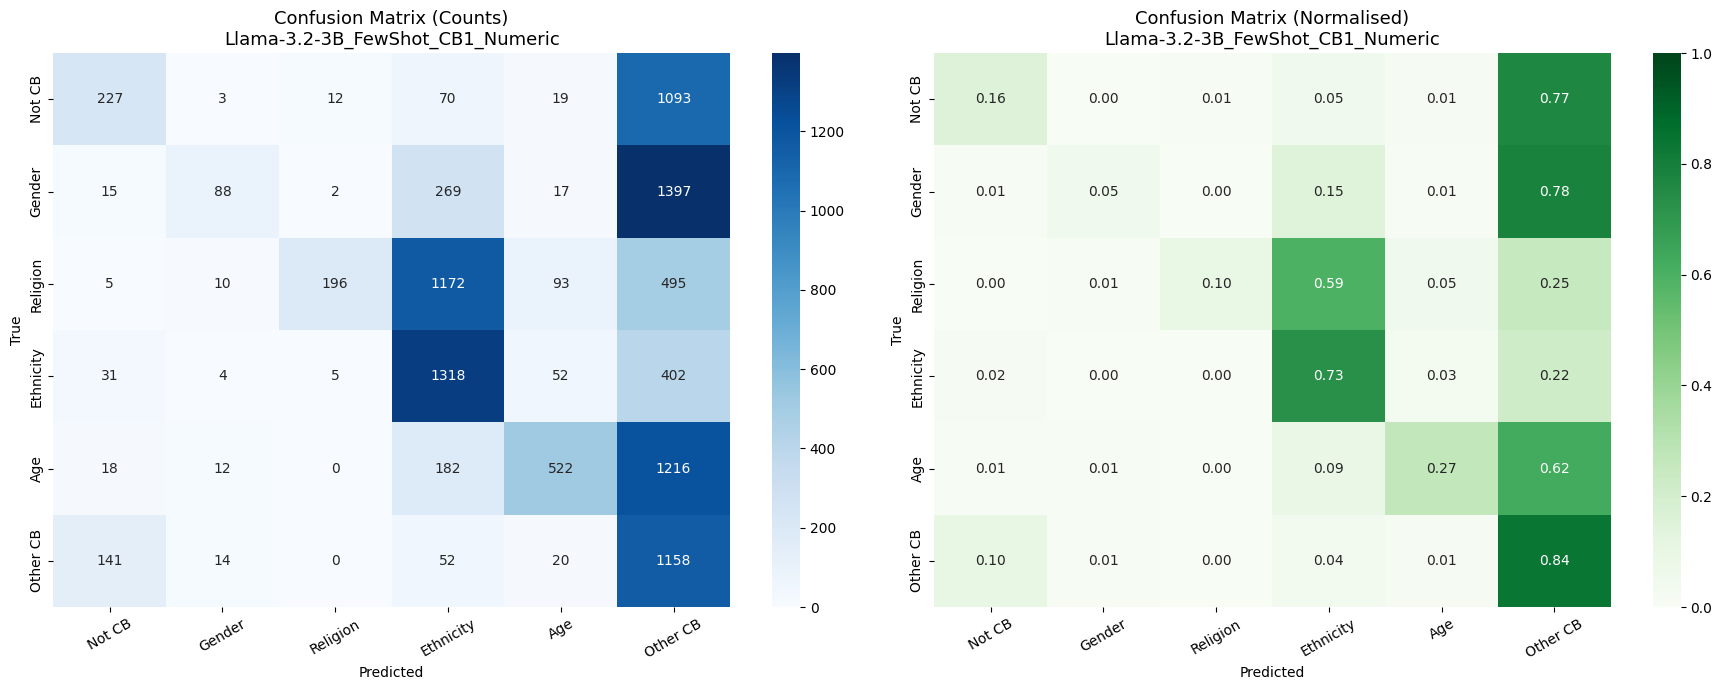

  Saved -> /content/drive/MyDrive/Results/CB1_Decoders/Llama-3.2-3B-Numeric/cm_Llama-3.2-3B_FewShot_CB1_Numeric.png


In [14]:
print("=" * 65)
print("FEW-SHOT INFERENCE  (Attempt 3)")
print(f"  Model    : {MODEL_NAME}")
print(f"  Examples : {len(few_shot_examples)} total ({N_EXAMPLES_PER_CLASS}/class × {NUM_LABELS} classes)")
print(f"  Format   : numeric labels 0-5  ← fixes Attempt 2 echo collapse")
print("=" * 65)

# Smoke test
_smoke_tweet_fs  = "You are so ugly nobody likes you"
_smoke_prompt_fs = build_prompt(_smoke_tweet_fs, few_shot_examples)
_smoke_inputs_fs = tokenizer(
    _smoke_prompt_fs, return_tensors="pt",
    truncation=True, max_length=1536
).to(model.device)
_smoke_in_len_fs = _smoke_inputs_fs["input_ids"].shape[1]

with torch.no_grad():
    _smoke_out_fs = model.generate(
        **_smoke_inputs_fs, max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False, pad_token_id=tokenizer.eos_token_id
    )

_smoke_generated_fs = tokenizer.decode(
    _smoke_out_fs[0][_smoke_in_len_fs:], skip_special_tokens=True
).strip()
_smoke_pred_fs = parse_label(_smoke_generated_fs)

print(f"Smoke test:")
print(f"  Input      : '{_smoke_tweet_fs}'")
print(f"  Generated  : '{_smoke_generated_fs}'   ← should be a single digit 0-5")
print(f"  Prediction : {_smoke_pred_fs} = {ID2LABEL[_smoke_pred_fs]}")
print()

_valid_fs = any(ch in _smoke_generated_fs for ch in "012345")
if not _valid_fs:
    print("WARNING: smoke test did not produce a digit. Review prompt before full run.")
else:
    print("Smoke test passed. Starting full few-shot run...")

y_pred_fs  = run_inference(x_test, examples=few_shot_examples, desc="Few-shot")
results_fs = evaluate_dataset(y_test, y_pred_fs, f"{MODEL_SHORT}_FewShot_CB1_Numeric")
results_fs["regime"] = "few-shot"

In [15]:
# Restore zero-shot results from Attempt 3 (already saved to Drive)
results_zs = {
    "macro_f1": 0.1280, "mcc": 0.0280,
    "accuracy": 0.1534, "macro_precision": 0.3313,
    "macro_recall": 0.1800, "weighted_f1": 0.1163,
    "balanced_accuracy": 0.1800, "regime": "zero-shot"
}
print("results_zs restored from Attempt 3.")

results_zs restored from Attempt 3.


---
## Step 15: Comparison + Full Attempt History

COMPARISON — Llama-3.2-3B | Attempt 3 (Numeric) | CB1 (6-Class)
   Regime  Macro F1    MCC  Accuracy  Macro P  Macro R  Weighted F1  Bal. Acc
Zero-Shot    0.1280 0.0280    0.1534   0.3313   0.1800       0.1163    0.1800
 Few-Shot    0.2951 0.2673    0.3397   0.5760   0.3565       0.2957    0.3565

FULL ATTEMPT HISTORY — Stage 1e CB1 Llama-3.2-3B
  Attempt                                ZS F1    FS F1  Note
  ----------------------------------------------------------------------
  Attempt 1 (original)                  0.0404   0.0404  Full-seq decode bug — complete collapse
  Attempt 2 (bug fixes)                 0.0911   0.0492  ZS real; FS echo collapse on prompt format
  Attempt 3 (numeric ZS)                0.1280     —     This run — zero-shot
  Attempt 3 (numeric FS)                  —      0.2951  This run — few-shot


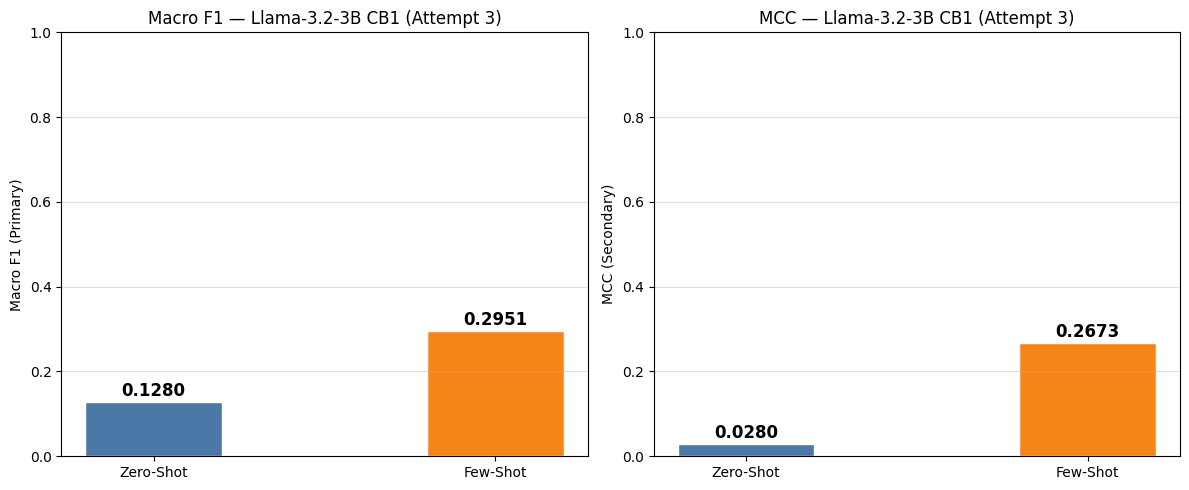

Chart saved -> /content/drive/MyDrive/Results/CB1_Decoders/Llama-3.2-3B-Numeric/zs_vs_fs_comparison_numeric.png


In [16]:
all_results = [results_zs, results_fs]
regimes     = ["Zero-Shot", "Few-Shot"]

rows = []
for r, regime in zip(all_results, regimes):
    rows.append({
        "Regime":      regime,
        "Macro F1":    round(r["macro_f1"],          4),
        "MCC":         round(r["mcc"],               4),
        "Accuracy":    round(r["accuracy"],          4),
        "Macro P":     round(r["macro_precision"],   4),
        "Macro R":     round(r["macro_recall"],      4),
        "Weighted F1": round(r["weighted_f1"],       4),
        "Bal. Acc":    round(r["balanced_accuracy"], 4),
    })

print("=" * 80)
print(f"COMPARISON — {MODEL_SHORT} | Attempt 3 (Numeric) | CB1 (6-Class)")
print("=" * 80)
print(pd.DataFrame(rows).to_string(index=False))

# Also print attempt history for thesis
print("\n" + "=" * 80)
print("FULL ATTEMPT HISTORY — Stage 1e CB1 Llama-3.2-3B")
print("=" * 80)
history = [
    ("Attempt 1 (original)",    0.0404, 0.0404, "Full-seq decode bug — complete collapse"),
    ("Attempt 2 (bug fixes)",   0.0911, 0.0492, "ZS real; FS echo collapse on prompt format"),
    (f"Attempt 3 (numeric ZS)", results_zs["macro_f1"], None,             "This run — zero-shot"),
    (f"Attempt 3 (numeric FS)", None,                   results_fs["macro_f1"], "This run — few-shot"),
]
print(f"  {'Attempt':<35} {'ZS F1':>8} {'FS F1':>8}  Note")
print("  " + "-" * 70)
for name, zs, fs, note in history:
    zs_str = f"{zs:.4f}" if zs is not None else "  —   "
    fs_str = f"{fs:.4f}" if fs is not None else "  —   "
    print(f"  {name:<35} {zs_str:>8} {fs_str:>8}  {note}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#4c78a8", "#f58518"]

f1s  = [r["macro_f1"] for r in all_results]
bars = axes[0].bar(regimes, f1s, color=colors, edgecolor="white", width=0.4)
for bar, v in zip(bars, f1s):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[0].set_title(f"Macro F1 — {MODEL_SHORT} CB1 (Attempt 3)", fontsize=12)
axes[0].set_ylabel("Macro F1 (Primary)"); axes[0].set_ylim(0, 1.0)
axes[0].grid(axis="y", alpha=0.4)

mccs  = [r["mcc"] for r in all_results]
bars2 = axes[1].bar(regimes, mccs, color=colors, edgecolor="white", width=0.4)
for bar, v in zip(bars2, mccs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[1].set_title(f"MCC — {MODEL_SHORT} CB1 (Attempt 3)", fontsize=12)
axes[1].set_ylabel("MCC (Secondary)"); axes[1].set_ylim(0, 1.0)
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "zs_vs_fs_comparison_numeric.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved -> {path}")

---
## Step 16: Save Results

In [17]:
csv_path = os.path.join(OUTPUT_DIR, "summary_metrics_numeric.csv")
pd.DataFrame([{
    "model":             MODEL_NAME,
    "model_short":       MODEL_SHORT,
    "stage":             f'Stage1e_{r["regime"].replace("-","")}_CB1_Numeric',
    "dataset":           "CB1",
    "regime":            r["regime"],
    "attempt":           3,
    "output_format":     "numeric_0_5",
    "test_samples":      len(y_test),
    "macro_f1":          round(r["macro_f1"],          4),
    "mcc":               round(r["mcc"],               4),
    "accuracy":          round(r["accuracy"],          4),
    "macro_precision":   round(r["macro_precision"],   4),
    "macro_recall":      round(r["macro_recall"],      4),
    "weighted_f1":       round(r["weighted_f1"],       4),
    "balanced_accuracy": round(r["balanced_accuracy"], 4),
} for r in all_results]).to_csv(csv_path, index=False)
print(f"Summary CSV saved -> {csv_path}")

for r, y_pred, regime in zip(all_results,
                              [y_pred_zs, y_pred_fs],
                              ["ZeroShot", "FewShot"]):
    pred_df = test_df[["text", "label"]].copy()
    pred_df["pred_id"]    = y_pred
    pred_df["pred_label"] = [ID2LABEL[p] for p in y_pred]
    pred_df["correct"]    = (test_df["label"].values == pred_df["pred_label"].values)
    ppath = os.path.join(OUTPUT_DIR, f"predictions_{regime}_CB1_Numeric.csv")
    pred_df.to_csv(ppath, index=False)
    print(f"Predictions saved -> {ppath}")

print(f"\nAll outputs in: {OUTPUT_DIR}")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        print(f"  {fname:<55} {os.path.getsize(fpath)/1024:.1f} KB")

Summary CSV saved -> /content/drive/MyDrive/Results/CB1_Decoders/Llama-3.2-3B-Numeric/summary_metrics_numeric.csv


NameError: name 'y_pred_zs' is not defined

---
## Step 17: Research Summary for Thesis

In [ ]:
summary = f"""
=============================================================================
STAGE 1e — CB1 DECODER BASELINE: RESEARCH SUMMARY (Attempt 3)
Llama-3.2-3B-Instruct | CB1 (6-Class) | Numeric Labels
=============================================================================

ATTEMPT HISTORY (for thesis documentation)
  Attempt 1 — Original notebook
    Bug: tokenizer.decode(outputs[0]) decoded full sequence including prompt.
    parse_label searched entire text → always found 'not_cyberbullying' first
    in system message label list → complete class collapse for both ZS & FS.
    ZS Macro F1: 0.0404  |  FS Macro F1: 0.0404

  Attempt 2 — Bug fixes (new-token decode + word-boundary parser)
    Bug 1 fixed: decode outputs[0][input_len:] — new tokens only.
    Bug 2 fixed: word-boundary regex for 'age' in keyword map.
    ZS result: real (0.0911), FS result: 0.0492 — collapsed again.
    Root cause: with 12 text-label examples, 3B model echoed prompt
    structure ('Category: other_cyberbullying') instead of just the label.
    L2 substring caught the label word inside the echoed text, causing all
    predictions to collapse to whichever class appeared in the echo.

  Attempt 3 — Numeric labels (this notebook)
    Key change: model outputs single digit 0-5, not text label names.
    One character cannot be echo-corrupted. MAX_NEW_TOKENS reduced to 3.
    Same fix used in old 4-class notebook (cb_multi_labeled_balanced)
    which achieved FS Macro F1 = 0.64 with this approach.

MODEL
  meta-llama/Llama-3.2-3B-Instruct | ~3.2B params | 4-bit NF4 | float16

DATASET: CB1
  6 classes | 75/25 stratified split seed=42 | TF-IDF dedup @0.90

RESULTS
  Zero-shot Macro F1 : {results_zs['macro_f1']:.4f}   MCC: {results_zs['mcc']:.4f}
  Few-shot  Macro F1 : {results_fs['macro_f1']:.4f}   MCC: {results_fs['mcc']:.4f}
"""
print(summary)